In [51]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math
from matplotlib import colors

In [52]:
# --- Subregions and colors ---
subregions = [(550, 800, 700, 950), (1100, 850, 20, 270)]  # y1,y2,x1,x2
colors = [(0, 255, 0), (0, 0, 255)]  # green, blue


# --- Draw rectangle safely ---
def draw_colored_rectangle(img, coords, color):
    if len(img.shape) == 2:  # grayscale → RGB
        img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    else:
        img_rgb = img.copy()
    y1, y2, x1, x2 = coords
    cv2.rectangle(img_rgb, (x1, y1), (x2, y2), color, 1)
    return img_rgb


def get_subregions_with_border(img, subregions, colors):
    sub_imgs = []
    for (coords, color) in zip(subregions, colors):
        y1, y2, x1, x2 = coords
        y1, y2 = sorted((y1, y2))
        x1, x2 = sorted((x1, x2))
        y2 = min(y2, img.shape[0])
        x2 = min(x2, img.shape[1])
        sub_img = img[y1:y2, x1:x2].copy()
        if sub_img.size == 0:
            continue
        height, width = sub_img.shape[:2]
        sub_img = draw_colored_rectangle(sub_img, (0, height-1, 0, width-1), color)
        sub_imgs.append(sub_img)
    return sub_imgs



In [ ]:
img = cv2.imread('Picture3.jpg')

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

img_greyscale = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

In [132]:
path2 = r'tonguedataset\Stain\47_巧克力.JPG'

subregions = [(210, 250, 240, 280), (380, 420, 190, 230)]

# Use np.fromfile + cv2.imdecode to handle Unicode paths
img_array = np.fromfile(path2, dtype=np.uint8)
img = cv2.imdecode(img_array,  cv2.IMREAD_COLOR_RGB)
img_greyscale = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

# Check if loaded correctly
if img is None:
    raise FileNotFoundError(f"Could not load image at {path2}")

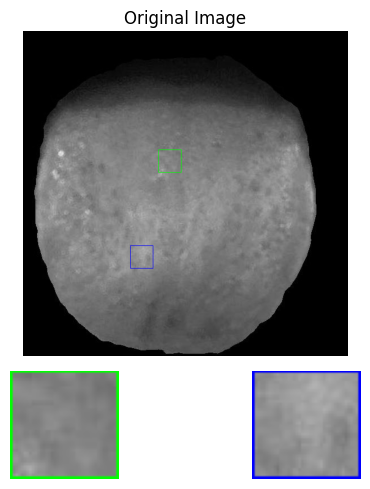

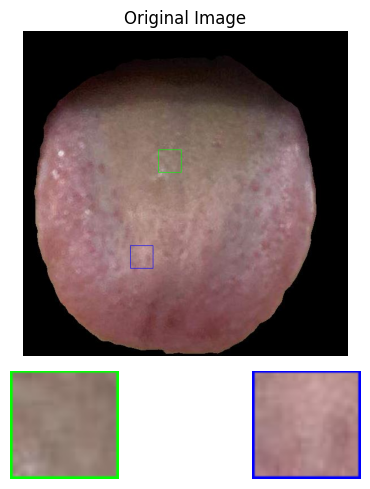

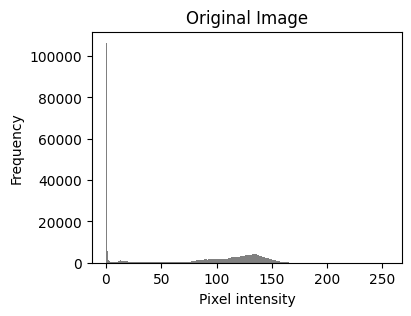

In [134]:
# Draw rectangles on a copy
img_boxed = img_greyscale.copy()
for coords, color in zip(subregions, colors):
    img_boxed = draw_colored_rectangle(img_boxed, coords, color)

# Extract subregions (only once)
sub_imgs = get_subregions_with_border(img_greyscale, subregions, colors)

# --- Plot layout ---
fig = plt.figure(figsize=(5, 5))
gs = fig.add_gridspec(2, len(subregions), height_ratios=[3, 1])

# Top: main image
ax_main = fig.add_subplot(gs[0, :])
ax_main.imshow(img_boxed, cmap='gray', vmin=0, vmax=255)
ax_main.set_title("Original Image")
ax_main.axis('off')

# Bottom: subregions
for i, sub_img in enumerate(sub_imgs):
    ax = fig.add_subplot(gs[1, i])
    ax.imshow(sub_img, cmap='gray', vmin=0, vmax=255)
    ax.axis('off')

plt.tight_layout()
plt.show()

img_boxed = img.copy()
for coords, color in zip(subregions, colors):
    img_boxed = draw_colored_rectangle(img_boxed, coords, color)

# Extract subregions (only once)
sub_imgs = get_subregions_with_border(img, subregions, colors)

# --- Plot layout ---
fig = plt.figure(figsize=(5, 5))
gs = fig.add_gridspec(2, len(subregions), height_ratios=[3, 1])

# Top: main image
ax_main = fig.add_subplot(gs[0, :])
ax_main.imshow(img_boxed)
ax_main.set_title("Original Image")
ax_main.axis('off')

# Bottom: subregions
for i, sub_img in enumerate(sub_imgs):
    ax = fig.add_subplot(gs[1, i])
    ax.imshow(sub_img)
    ax.axis('off')

plt.tight_layout()
plt.show()

plt.figure(figsize=(4, 3))
plt.hist(img_greyscale.ravel(), bins=256, range=(0, 255), color='gray')
plt.title("Original Image")
plt.xlabel("Pixel intensity")
plt.ylabel("Frequency")
plt.show()

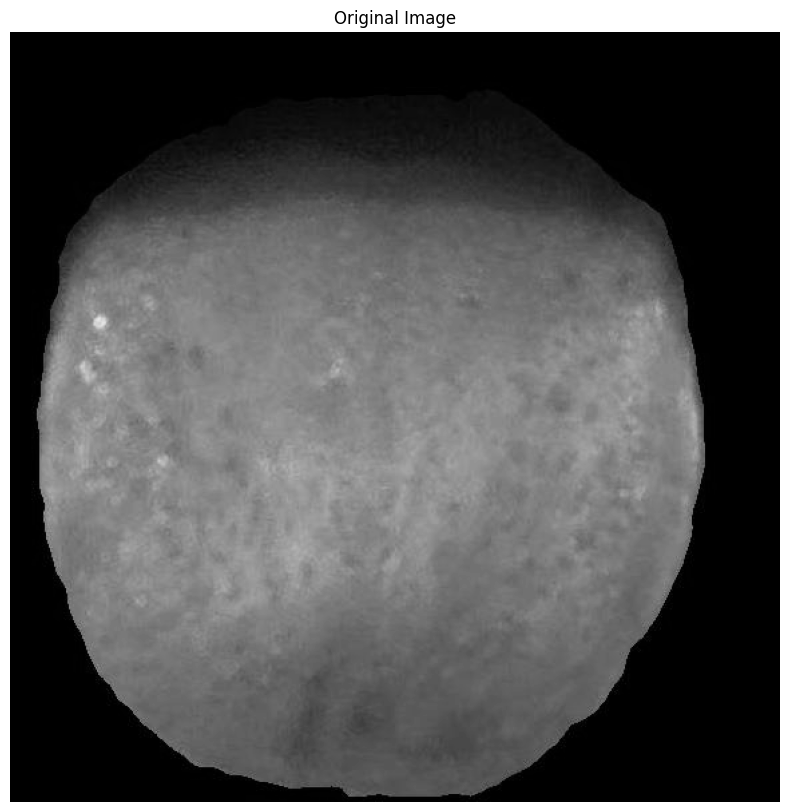

In [135]:
plt.figure(figsize=(10, 10))
plt.imshow(img_greyscale, cmap='gray', vmin=0, vmax=255)
plt.title("Original Image")
plt.axis('off')
plt.show()

In [136]:
def contrast_stretching(img):
    img = img.astype(np.float32)
    min_val = np.min(img)
    max_val = np.max(img)
    
    if max_val == min_val: 
        return np.zeros_like(img, dtype=np.uint8)
    
    img = (img - min_val) / (max_val - min_val) * 255
    return img.astype(np.uint8)

In [137]:
def filter(max_val, min_val, alpha):
    if min_val>0:
        ratio = max_val / (min_val + 1e-5)
        return alpha * pow(ratio, alpha) + math.log(ratio)
    return 0.0

def EMME(img, kernel, alpha=1.0):
    h, w = img.shape

    how_many_h = h // kernel

    EMME = 0.0

    for i in range(how_many_h):
        for j in range(how_many_h):
            window = img[i*kernel:(i+1)*kernel, j*kernel:(j+1)*kernel]
            max = np.max(window)
            min = np.min(window)

            EMME += filter(max, min, alpha)

    EMME = EMME / (how_many_h * how_many_h)
    return EMME

In [138]:
print(EMME(img_greyscale,3))

1.3015621777591384


In [139]:
def histogram_equalization(img):

    # cdf of image
    hist,bins = np.histogram(img.flatten(),256,[0,256])
 
    cdf = hist.cumsum()

    sk = (cdf - cdf.min()) * 255 / (cdf.max() - cdf.min()) 
    sk = sk.astype(np.uint8)
    
    new_img = sk[img]
    return new_img

In [140]:
def clahe_image(img, clip=40.0, size=8):
    clahe = cv2.createCLAHE(clipLimit=clip, tileGridSize=(size,size))
    cl1 = clahe.apply(img)
    return cl1


In [141]:
def gamma_correction(img, gamma):
    img_normalized = img / 255.0

    transformed = np.power(img_normalized, gamma)
    transformed = np.uint8(transformed * 255)
    
    return transformed

In [142]:
def median_filter(image, kernel_size):
    h, w = image.shape

    pad = kernel_size // 2
    padded_img = np.pad(image, pad, mode='edge')
    img_new = np.zeros((h, w), dtype=float)

    for i in range(h):
        for j in range(w):
            window = padded_img[i:i+kernel_size, j:j+kernel_size]
            new_pixel = np.median(window)
            img_new[i, j] = new_pixel
    img_new = np.clip(img_new, 0, 255).astype(np.uint8)
    return img_new


def color_enhancement(img, enhance, gamma=0.8, clahe=40):
    img = img.astype(np.uint8)
    img = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    h, s, v = cv2.split(img)

    s_temp = median_filter(s,3)
    
    if enhance == 'stretch':
        v_new = contrast_stretching(v)
        s_temp = contrast_stretching(s_temp)
    elif enhance == 'histo':
        v_new = histogram_equalization(v)
        s_temp = histogram_equalization(s_temp)
    elif enhance == 'gamma':
        v_new = gamma_correction(v, gamma)
        s_temp = gamma_correction(s_temp, gamma)
    elif enhance =='clahe':
        v_new = clahe_image(v, clahe)
        s_temp = clahe_image(s_temp, clahe)
    
    plt.figure(figsize=(5, 3))
    plt.hist(v_new.ravel(), bins=256, range=(0, 255), color='gray')
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Frequency")
    plt.show()

    hsv_enhanced = cv2.merge([h, s_temp, v_new])
    rgb_enhanced = cv2.cvtColor(hsv_enhanced, cv2.COLOR_HSV2RGB)
    
    '''
    r, g, b = cv2.split(img)

    rNew = (r/v)*v_new
    gNew = (g/v)*v_new
    bNew = (b/v)*v_new
    
    rgb_enhanced = cv2.merge([
        np.clip(rNew, 0, 255).astype(np.uint8),
        np.clip(gNew, 0, 255).astype(np.uint8),
        np.clip(bNew, 0, 255).astype(np.uint8)
    ])
    '''
    hist, bins = np.histogram(v_new.flatten(), 256, [0, 256])



    return rgb_enhanced, hist

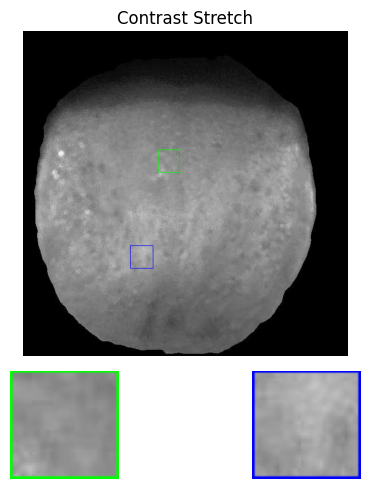

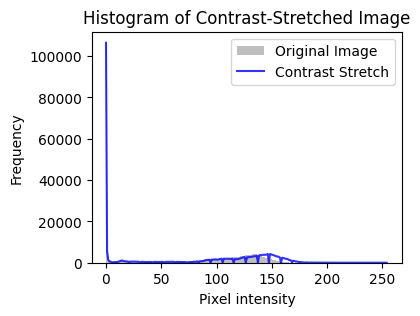

1.351264060517845


In [143]:
img_stretch = contrast_stretching(img_greyscale)


# Draw rectangles on a copy
img_boxed = img_stretch.copy()
for coords, color in zip(subregions, colors):
    img_boxed = draw_colored_rectangle(img_boxed, coords, color)

# Extract subregions (only once)
sub_imgs = get_subregions_with_border(img_stretch, subregions, colors)

# --- Plot layout ---
fig = plt.figure(figsize=(5, 5))
gs = fig.add_gridspec(2, len(subregions), height_ratios=[3, 1])

# Top: main image
ax_main = fig.add_subplot(gs[0, :])
ax_main.imshow(img_boxed, cmap='gray', vmin=0, vmax=255)
ax_main.set_title("Contrast Stretch")
ax_main.axis('off')

# Bottom: subregions
for i, sub_img in enumerate(sub_imgs):
    ax = fig.add_subplot(gs[1, i])
    ax.imshow(sub_img)
    ax.axis('off')

plt.tight_layout()
plt.show()

plt.figure(figsize=(4, 3))

plt.hist(img_greyscale.ravel(), bins=256, range=(0, 255), color='gray', alpha=0.5, label='Original Image')

hist_stretch, bins = np.histogram(img_stretch.ravel(), bins=256, range=(0, 255))
plt.plot(bins[:-1], hist_stretch, color='blue', alpha=0.8, label='Contrast Stretch')

plt.title("Histogram of Contrast-Stretched Image")
plt.xlabel("Pixel intensity")
plt.ylabel("Frequency")
plt.legend()
plt.show()

print(EMME(img_stretch,3))

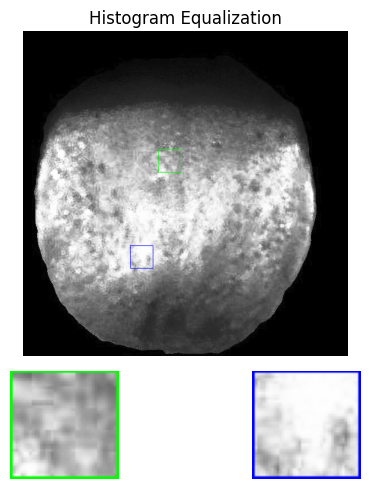

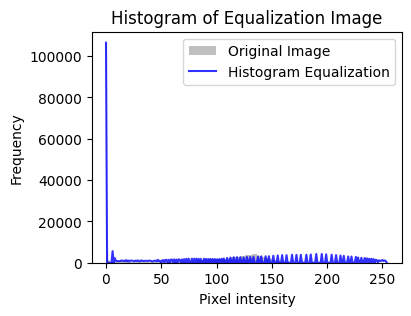

0.9887110759234109


In [144]:
img_histo = histogram_equalization(img_greyscale)

# Draw rectangles on a copy
img_boxed = img_histo.copy()
for coords, color in zip(subregions, colors):
    img_boxed = draw_colored_rectangle(img_boxed, coords, color)

# Extract subregions (only once)
sub_imgs = get_subregions_with_border(img_histo, subregions, colors)

# --- Plot layout ---
fig = plt.figure(figsize=(5, 5))
gs = fig.add_gridspec(2, len(subregions), height_ratios=[3, 1])

# Top: main image
ax_main = fig.add_subplot(gs[0, :])
ax_main.imshow(img_boxed, cmap='gray', vmin=0, vmax=255)
ax_main.set_title("Histogram Equalization")
ax_main.axis('off')

# Bottom: subregions
for i, sub_img in enumerate(sub_imgs):
    ax = fig.add_subplot(gs[1, i])
    ax.imshow(sub_img)
    ax.axis('off')

plt.tight_layout()
plt.show()

plt.figure(figsize=(4, 3))
plt.hist(img_greyscale.ravel(), bins=256, range=(0, 255), color='gray', alpha=0.5, label='Original Image')

hist_stretch, bins = np.histogram(img_histo.ravel(), bins=256, range=(0, 255))
plt.plot(bins[:-1], hist_stretch, color='blue', alpha=0.8, label='Histogram Equalization')

plt.title("Histogram of Equalization Image")
plt.xlabel("Pixel intensity")
plt.ylabel("Frequency")
plt.legend()
plt.show()

print(EMME(img_histo,3))

In [145]:
img_temp = cv2.imread('histo1pic.png')

img_temp = cv2.cvtColor(img_temp, cv2.COLOR_BGRA2GRAY)

print(EMME(img_temp,3))

1.0898291751036346


In [146]:
img_temp = cv2.imread('histo2pic.png')

img_temp = cv2.cvtColor(img_temp, cv2.COLOR_BGRA2GRAY)

print(EMME(img_temp,3))

1.2459095500314574


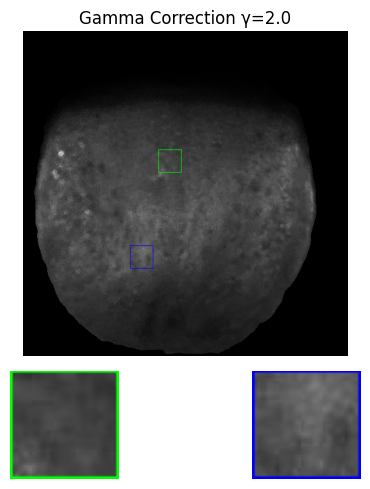

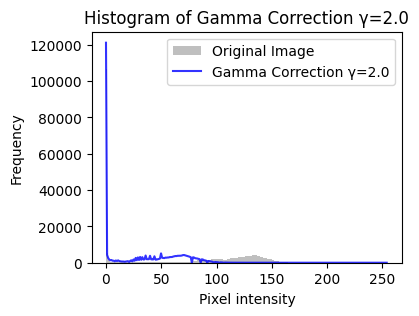

0.8414072872845569


In [147]:
img_histo = gamma_correction(img_greyscale, 2.0)

# Draw rectangles on a copy
img_boxed = img_histo.copy()
for coords, color in zip(subregions, colors):
    img_boxed = draw_colored_rectangle(img_boxed, coords, color)

# Extract subregions (only once)
sub_imgs = get_subregions_with_border(img_histo, subregions, colors)

# --- Plot layout ---
fig = plt.figure(figsize=(5, 5))
gs = fig.add_gridspec(2, len(subregions), height_ratios=[3, 1])

# Top: main image
ax_main = fig.add_subplot(gs[0, :])
ax_main.imshow(img_boxed, cmap='gray', vmin=0, vmax=255)
ax_main.set_title("Gamma Correction γ=2.0")
ax_main.axis('off')

# Bottom: subregions
for i, sub_img in enumerate(sub_imgs):
    ax = fig.add_subplot(gs[1, i])
    ax.imshow(sub_img)
    ax.axis('off')

plt.tight_layout()
plt.show()

plt.figure(figsize=(4, 3))
plt.hist(img_greyscale.ravel(), bins=256, range=(0, 255), color='gray', alpha=0.5, label='Original Image')

hist_stretch, bins = np.histogram(img_histo.ravel(), bins=256, range=(0, 255))
plt.plot(bins[:-1], hist_stretch, color='blue', alpha=0.8, label='Gamma Correction γ=2.0')

plt.title("Histogram of Gamma Correction γ=2.0")
plt.xlabel("Pixel intensity")
plt.ylabel("Frequency")
plt.legend()
plt.show()

print(EMME(img_histo,3))

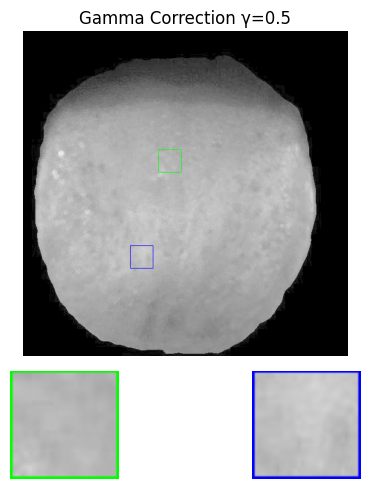

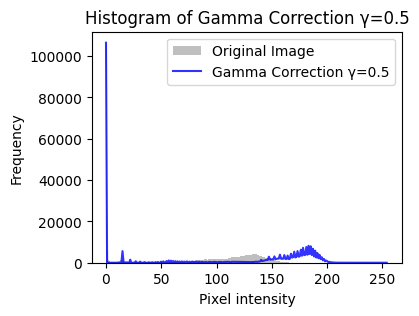

0.8016169781855617


In [148]:
img_histo = gamma_correction(img_greyscale, 0.5)

# Draw rectangles on a copy
img_boxed = img_histo.copy()
for coords, color in zip(subregions, colors):
    img_boxed = draw_colored_rectangle(img_boxed, coords, color)

# Extract subregions (only once)
sub_imgs = get_subregions_with_border(img_histo, subregions, colors)

# --- Plot layout ---
fig = plt.figure(figsize=(5, 5))
gs = fig.add_gridspec(2, len(subregions), height_ratios=[3, 1])

# Top: main image
ax_main = fig.add_subplot(gs[0, :])
ax_main.imshow(img_boxed, cmap='gray', vmin=0, vmax=255)
ax_main.set_title("Gamma Correction γ=0.5")
ax_main.axis('off')

# Bottom: subregions
for i, sub_img in enumerate(sub_imgs):
    ax = fig.add_subplot(gs[1, i])
    ax.imshow(sub_img)
    ax.axis('off')

plt.tight_layout()
plt.show()

plt.figure(figsize=(4, 3))
plt.hist(img_greyscale.ravel(), bins=256, range=(0, 255), color='gray', alpha=0.5, label='Original Image')

hist_stretch, bins = np.histogram(img_histo.ravel(), bins=256, range=(0, 255))
plt.plot(bins[:-1], hist_stretch, color='blue', alpha=0.8, label='Gamma Correction γ=0.5')

plt.title("Histogram of Gamma Correction γ=0.5")
plt.xlabel("Pixel intensity")
plt.ylabel("Frequency")
plt.legend()
plt.show()

print(EMME(img_histo,3))

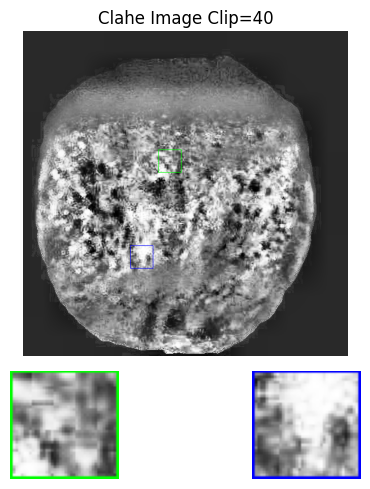

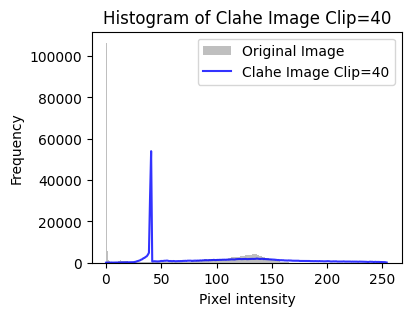

1.707339928510393


In [149]:
img_histo = clahe_image(img_greyscale)

# Draw rectangles on a copy
img_boxed = img_histo.copy()
for coords, color in zip(subregions, colors):
    img_boxed = draw_colored_rectangle(img_boxed, coords, color)

# Extract subregions (only once)
sub_imgs = get_subregions_with_border(img_histo, subregions, colors)

# --- Plot layout ---
fig = plt.figure(figsize=(5, 5))
gs = fig.add_gridspec(2, len(subregions), height_ratios=[3, 1])

# Top: main image
ax_main = fig.add_subplot(gs[0, :])
ax_main.imshow(img_boxed, cmap='gray', vmin=0, vmax=255)
ax_main.set_title("Clahe Image Clip=40")
ax_main.axis('off')

# Bottom: subregions
for i, sub_img in enumerate(sub_imgs):
    ax = fig.add_subplot(gs[1, i])
    ax.imshow(sub_img)
    ax.axis('off')

plt.tight_layout()
plt.show()

plt.figure(figsize=(4, 3))
plt.hist(img_greyscale.ravel(), bins=256, range=(0, 255), color='gray', alpha=0.5, label='Original Image')

hist_stretch, bins = np.histogram(img_histo.ravel(), bins=256, range=(0, 255))
plt.plot(bins[:-1], hist_stretch, color='blue', alpha=0.8, label='Clahe Image Clip=40')

plt.title("Histogram of Clahe Image Clip=40")
plt.xlabel("Pixel intensity")
plt.ylabel("Frequency")
plt.legend()
plt.show()

print(EMME(img_histo,3))

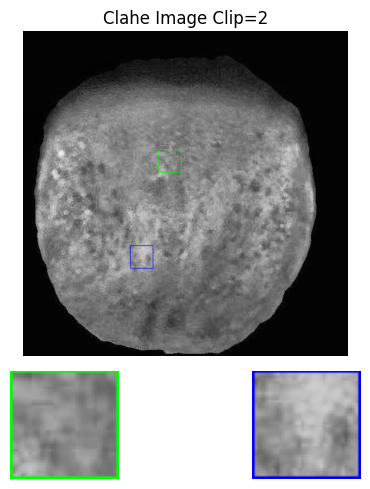

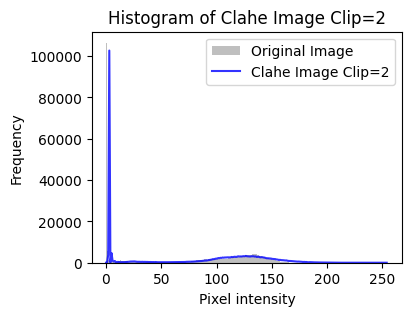

1.4964664232078402


In [150]:
img_histo = clahe_image(img_greyscale,clip=2.0)

# Draw rectangles on a copy
img_boxed = img_histo.copy()
for coords, color in zip(subregions, colors):
    img_boxed = draw_colored_rectangle(img_boxed, coords, color)

# Extract subregions (only once)
sub_imgs = get_subregions_with_border(img_histo, subregions, colors)

# --- Plot layout ---
fig = plt.figure(figsize=(5, 5))
gs = fig.add_gridspec(2, len(subregions), height_ratios=[3, 1])

# Top: main image
ax_main = fig.add_subplot(gs[0, :])
ax_main.imshow(img_boxed, cmap='gray', vmin=0, vmax=255)
ax_main.set_title("Clahe Image Clip=2")
ax_main.axis('off')

# Bottom: subregions
for i, sub_img in enumerate(sub_imgs):
    ax = fig.add_subplot(gs[1, i])
    ax.imshow(sub_img)
    ax.axis('off')

plt.tight_layout()
plt.show()

plt.figure(figsize=(4, 3))
plt.hist(img_greyscale.ravel(), bins=256, range=(0, 255), color='gray', alpha=0.5, label='Original Image')

hist_stretch, bins = np.histogram(img_histo.ravel(), bins=256, range=(0, 255))
plt.plot(bins[:-1], hist_stretch, color='blue', alpha=0.8, label='Clahe Image Clip=2')

plt.title("Histogram of Clahe Image Clip=2")
plt.xlabel("Pixel intensity")
plt.ylabel("Frequency")
plt.legend()
plt.show()

print(EMME(img_histo,3))

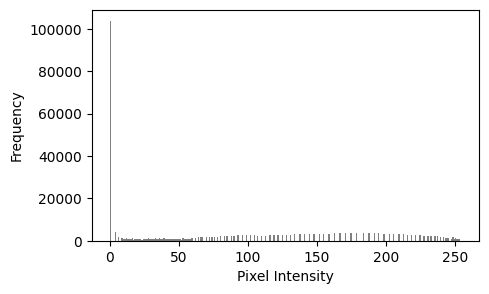

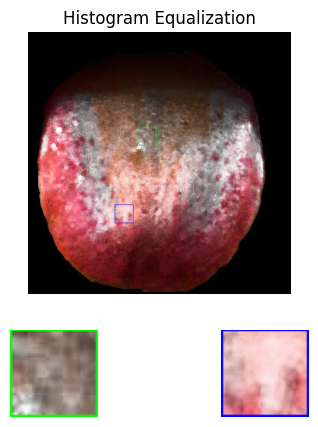

In [151]:
img_enchanced, hist = color_enhancement(img, 'histo')

# Draw rectangles on a copy
img_boxed = img_enchanced.copy()
for coords, color in zip(subregions, colors):
    img_boxed = draw_colored_rectangle(img_boxed, coords, color)

# Extract subregions (only once)
sub_imgs = get_subregions_with_border(img_enchanced, subregions, colors)

# --- Plot layout ---
fig = plt.figure(figsize=(5, 5))
gs = fig.add_gridspec(2, len(subregions), height_ratios=[3, 1])

# Top: main image
ax_main = fig.add_subplot(gs[0, :])
ax_main.imshow(img_boxed, cmap='gray', vmin=0, vmax=255)
ax_main.set_title("Histogram Equalization")
ax_main.axis('off')

# Bottom: subregions
for i, sub_img in enumerate(sub_imgs):
    ax = fig.add_subplot(gs[1, i])
    ax.imshow(sub_img)
    ax.axis('off')

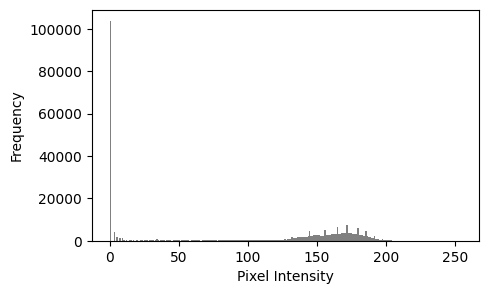

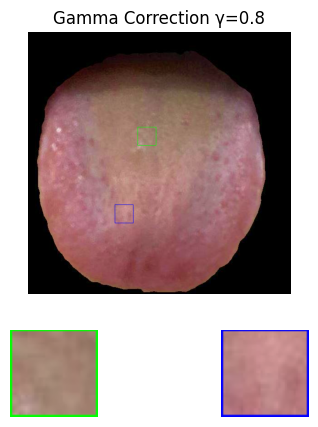

In [152]:
img_enchanced, hist = color_enhancement(img, 'gamma')

# Draw rectangles on a copy
img_boxed = img_enchanced.copy()
for coords, color in zip(subregions, colors):
    img_boxed = draw_colored_rectangle(img_boxed, coords, color)

# Extract subregions (only once)
sub_imgs = get_subregions_with_border(img_enchanced, subregions, colors)

# --- Plot layout ---
fig = plt.figure(figsize=(5, 5))
gs = fig.add_gridspec(2, len(subregions), height_ratios=[3, 1])

# Top: main image
ax_main = fig.add_subplot(gs[0, :])
ax_main.imshow(img_boxed, cmap='gray', vmin=0, vmax=255)
ax_main.set_title("Gamma Correction γ=0.8")
ax_main.axis('off')

# Bottom: subregions
for i, sub_img in enumerate(sub_imgs):
    ax = fig.add_subplot(gs[1, i])
    ax.imshow(sub_img)
    ax.axis('off')

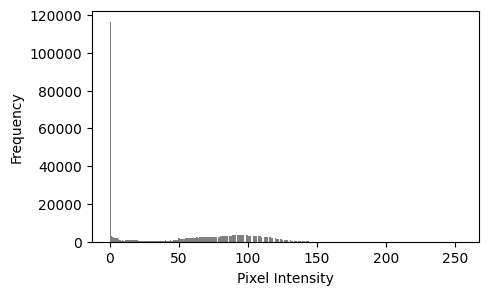

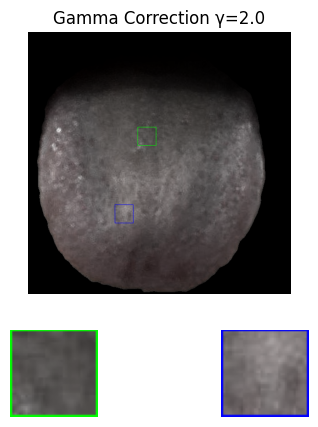

In [153]:
img_enchanced, hist = color_enhancement(img, 'gamma', gamma=2.0)

# Draw rectangles on a copy
img_boxed = img_enchanced.copy()
for coords, color in zip(subregions, colors):
    img_boxed = draw_colored_rectangle(img_boxed, coords, color)

# Extract subregions (only once)
sub_imgs = get_subregions_with_border(img_enchanced, subregions, colors)

# --- Plot layout ---
fig = plt.figure(figsize=(5, 5))
gs = fig.add_gridspec(2, len(subregions), height_ratios=[3, 1])

# Top: main image
ax_main = fig.add_subplot(gs[0, :])
ax_main.imshow(img_boxed, cmap='gray', vmin=0, vmax=255)
ax_main.set_title("Gamma Correction γ=2.0")
ax_main.axis('off')

# Bottom: subregions
for i, sub_img in enumerate(sub_imgs):
    ax = fig.add_subplot(gs[1, i])
    ax.imshow(sub_img)
    ax.axis('off')

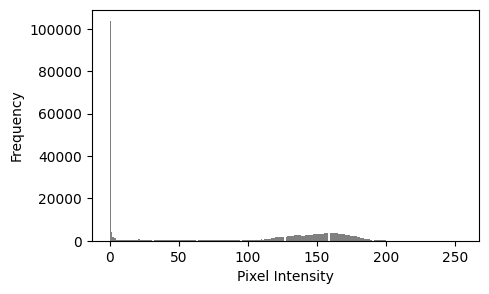

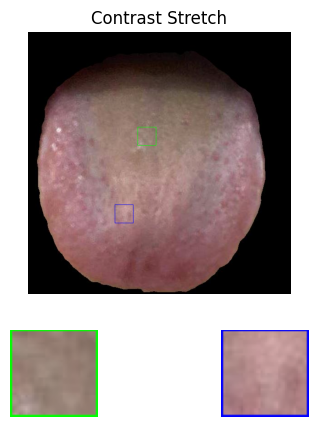

In [154]:
img_enchanced, hist = color_enhancement(img, 'stretch')

# Draw rectangles on a copy
img_boxed = img_enchanced.copy()
for coords, color in zip(subregions, colors):
    img_boxed = draw_colored_rectangle(img_boxed, coords, color)

# Extract subregions (only once)
sub_imgs = get_subregions_with_border(img_enchanced, subregions, colors)

# --- Plot layout ---
fig = plt.figure(figsize=(5, 5))
gs = fig.add_gridspec(2, len(subregions), height_ratios=[3, 1])

# Top: main image
ax_main = fig.add_subplot(gs[0, :])
ax_main.imshow(img_boxed, cmap='gray', vmin=0, vmax=255)
ax_main.set_title("Contrast Stretch")
ax_main.axis('off')

# Bottom: subregions
for i, sub_img in enumerate(sub_imgs):
    ax = fig.add_subplot(gs[1, i])
    ax.imshow(sub_img)
    ax.axis('off')

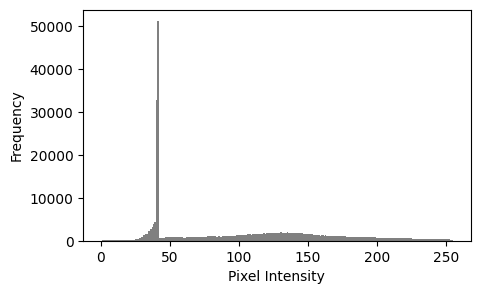

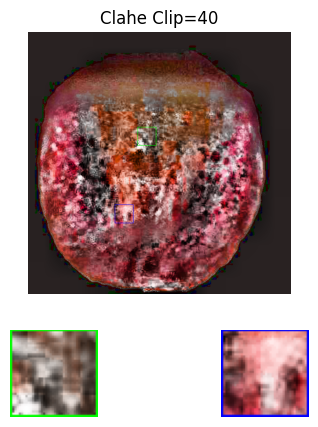

In [155]:
img_enchanced, hist = color_enhancement(img, 'clahe')

# Draw rectangles on a copy
img_boxed = img_enchanced.copy()
for coords, color in zip(subregions, colors):
    img_boxed = draw_colored_rectangle(img_boxed, coords, color)

# Extract subregions (only once)
sub_imgs = get_subregions_with_border(img_enchanced, subregions, colors)

# --- Plot layout ---
fig = plt.figure(figsize=(5, 5))
gs = fig.add_gridspec(2, len(subregions), height_ratios=[3, 1])

# Top: main image
ax_main = fig.add_subplot(gs[0, :])
ax_main.imshow(img_boxed, cmap='gray', vmin=0, vmax=255)
ax_main.set_title("Clahe Clip=40")
ax_main.axis('off')

# Bottom: subregions
for i, sub_img in enumerate(sub_imgs):
    ax = fig.add_subplot(gs[1, i])
    ax.imshow(sub_img)
    ax.axis('off')

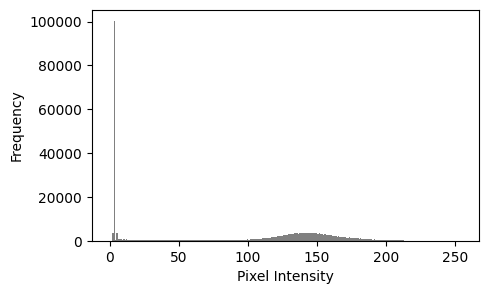

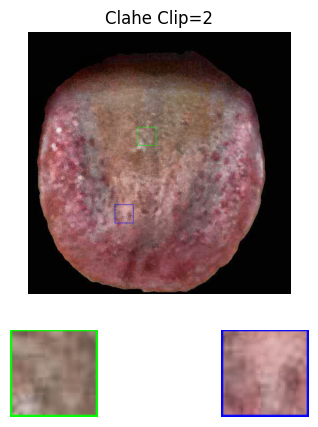

In [156]:
img_enchanced, hist = color_enhancement(img, 'clahe', clahe=2)

# Draw rectangles on a copy
img_boxed = img_enchanced.copy()
for coords, color in zip(subregions, colors):
    img_boxed = draw_colored_rectangle(img_boxed, coords, color)

# Extract subregions (only once)
sub_imgs = get_subregions_with_border(img_enchanced, subregions, colors)

# --- Plot layout ---
fig = plt.figure(figsize=(5, 5))
gs = fig.add_gridspec(2, len(subregions), height_ratios=[3, 1])

# Top: main image
ax_main = fig.add_subplot(gs[0, :])
ax_main.imshow(img_boxed, cmap='gray', vmin=0, vmax=255)
ax_main.set_title("Clahe Clip=2")
ax_main.axis('off')

# Bottom: subregions
for i, sub_img in enumerate(sub_imgs):
    ax = fig.add_subplot(gs[1, i])
    ax.imshow(sub_img)
    ax.axis('off')